<a href="https://colab.research.google.com/github/allendepablo22-web/Proyectos-Pablo-Allende/blob/main/Bots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chat bot**


#   **Realizamos un Diagrama del árbol del bot escogido:**

In [ ]:
# Diagrama de árbol del programa
BOT DE ASISTENTE DE COMPRAS
│
├── Variables globales
│   ├── productos
│   ├── precios
│   ├── carrito_cantidades
│   └── historial_compras
│
├── Funciones
│   ├── mostrar_productos()
│   │     └── imprime lista de productos y precios
│   │
│   ├── comprar_producto()
│   │     ├── mostrar_productos()
│   │     ├── input: número de producto
│   │     ├── input: cantidad
│   │     └── actualiza carrito_cantidades
│   │
│   ├── ver_carrito()
│   │     ├── recorre productos
│   │     ├── calcula subtotal
│   │     └── imprime total
│   │
│   ├── finalizar_compra()
│   │     ├── verifica si carrito vacío
│   │     ├── ver_carrito()
│   │     ├── guarda historial_compras
│   │     └── vacía carrito_cantidades
│   │
│   └── menu()
│         ├── bucle while True
│         ├── input opción
│         ├── if/elif:
│         │      ├── "1" → mostrar_productos()
│         │      ├── "2" → comprar_producto()
│         │      ├── "3" → ver_carrito()
│         │      ├── "4" → finalizar_compra()
│         │      └── "5" → salir
│         └── else → mensaje de error
│
└── Ejecución
    └── menu()   ← punto de inicio


--- MENÚ PRINCIPAL ---

1. Ver lista de productos
2. Comprar producto
3. Ver carrito
4. Agregar producto
5. Finalizar compra
6. Salir
Seleccione una opción: 1

--- Lista de Productos Disponibles ---
1. Leche - $1200
2. Pan - $800
3. Huevos - $1500
4. Queso - $2500
5. Manzanas - $900
--------------------------------------

--- MENÚ PRINCIPAL ---

1. Ver lista de productos
2. Comprar producto
3. Ver carrito
4. Agregar producto
5. Finalizar compra
6. Salir
Seleccione una opción: 4

Ingrese el nombre del nuevo producto: Papa
Ingrese el precio de Papa: 2500
✅ Producto 'Papa' agregado con precio $2500.

--- MENÚ PRINCIPAL ---

1. Ver lista de productos
2. Comprar producto
3. Ver carrito
4. Agregar producto
5. Finalizar compra
6. Salir
Seleccione una opción: 1

--- Lista de Productos Disponibles ---
1. Leche - $1200
2. Pan - $800
3. Huevos - $1500
4. Queso - $2500
5. Manzanas - $900
6. Papa - $2500
--------------------------------------

--- MENÚ PRINCIPAL ---

1. Ver lista de productos
2. C

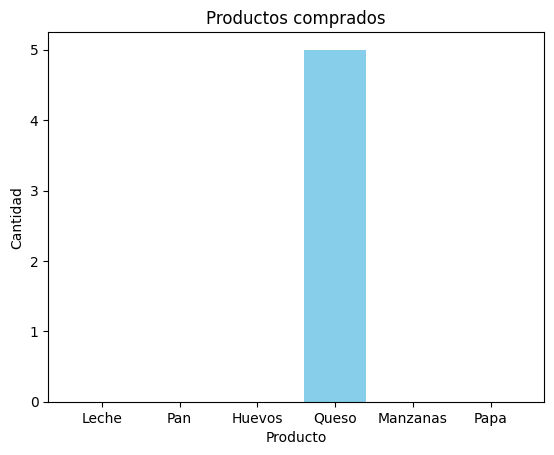


--- MENÚ PRINCIPAL ---

1. Ver lista de productos
2. Comprar producto
3. Ver carrito
4. Agregar producto
5. Finalizar compra
6. Salir


In [ ]:
# --- BOT DE ASISTENTE DE COMPRAS --- HECHO CON DICCIONARIO Y COMENTADO VERSIÓN FINAL
import matplotlib.pyplot as plt     # Importamos matplotlib para poder hacer gráficos de barras

# Diccionario de productos con precios. Este es un diccionario inicial de productos.
productos = {
    "Leche": 1200,
    "Pan": 800,
    "Huevos": 1500,
    "Queso": 2500,
    "Manzanas": 900
}   # Diccionario inicial de productos (clave = nombre, valor = precio)

# Carrito: diccionario con cantidades inicializadas en 0
carrito = {p: 0 for p in productos}   # Creamos un diccionario donde cada producto empieza con cantidad = 0

# Historial global de compras
historial_compras = {p: 0 for p in productos}   # Otro diccionario para acumular compras hechas (producto es igual a cantidad total)

# --- FUNCIONES ---

def mostrar_productos(): #Esta función se utiliza para mostrar el listado de productos disponibles.
    print("\n--- Lista de Productos Disponibles ---")   # Encabezado
    for i, (nombre, precio) in enumerate(productos.items(), start=1):   # Recorremos el diccionario con índice
        print(f"{i}. {nombre} - ${precio}")   # Mostramos número, nombre y precio con f-string
    print("--------------------------------------")   # Separador visual


def comprar_producto(): #Esta función se utiliza para comprar los productos y sus cantidades.
    mostrar_productos()   # Llamamos a la Función mostrar_productos para mostrar la lista antes de pedir la elección
    lista_productos = list(productos.keys())   # Definimos una variable local para guardar los nombres de productos en una lista para indexarlos

    try: # Bloque donde puede ocurrir un error. Si el usuario escribe algo que sea invalido, ocurre un ValueError y salta al except.
        opcion = int(input("Ingrese el número del producto que desea comprar: "))   # Pedimos número de producto
        if 1 <= opcion <= len(lista_productos):   # Validamos que esté dentro de rango
            nombre = lista_productos[opcion-1]   # Obtenemos el nombre a partir del índice, ponemos -1 para que al elegir el numero corresponda con el indice
            cantidad = int(input(f"Ingrese la cantidad de {nombre} que desea comprar: "))   # Pedimos cantidad
            if cantidad > 0:   # Validamos que sea positiva
                carrito[nombre] += cantidad   # Sumamos al carrito
                print(f"✅ Se agregaron {cantidad} unidad(es) de {nombre} al carrito.")   # Confirmación
            else:
                print("❌ Error: debe ingresar un número válido mayor a 0.")   # Error si puso 0 o negativo
        else:
            print("❌ Error: opción inválida.")   # Error si puso un número fuera de rango
    except ValueError:   # Si escribe algo que no es número
        print("❌ Error: debe ingresar un número.")
    print("--------------------------------------")   # Separador visual


def ver_carrito(): #Esta función se utiliza para ver en el carrito los productos, cantidades, precios y total gastado hasta el momento.
    print("\n--- Carrito de Compras ---")   # Encabezado
    total = 0   # Variable local que acumula el costo total
    vacio = True   # Variable local para detectar si el carrito está vacío
    for nombre, cantidad in carrito.items():   # Recorremos cada producto y su cantidad
        if cantidad > 0:   # Si hay algo comprado de ese producto
            vacio = False   # Entonces no está vacío
            subtotal = productos[nombre] * cantidad   # Precio × cantidad
            print(f"{nombre} x {cantidad} = ${subtotal}")   # Mostramos detalle
            total += subtotal   # Sumamos al total
    if vacio:   # Si nunca encontró productos con cantidad > 0
        print("🛒 El carrito está vacío.")   # Mensaje de vacío
    else:
        print(f"TOTAL: ${total}")   # Mostramos el total
    print("--------------------------------------")   # Separador visual


def finalizar_compra(): #Esta función se utiliza para finalizar la compra parcialmente, muestra el carrito al momento, da un resumen
                        #de las compras y grafica. Deja el carrito en 0 y permite ingresar otras compras.
    if sum(carrito.values()) == 0:   # Validacion si las cantidades son 0
        print("\n⚠️ No puede finalizar la compra, el carrito está vacío.")   # Error si no hay nada
        return   # Salimos de la función

    print("\n✅ Compra finalizada. Resumen:")   # Confirmación
    ver_carrito()   # Llamamos a la Función ver_carrito para ver lo que había en el carrito

    # Guardar en historial acumulando cantidades
    for nombre, cantidad in carrito.items():   # Recorremos cada producto comprado
        historial_compras[nombre] += cantidad   # Sumamos al historial global

    graficar_compras()   # Llamamos a la Función para generar el gráfico con todo el historial acumulado

    # Vaciar carrito (volver todas las cantidades a 0)
    for nombre in carrito:
        carrito[nombre] = 0


def graficar_compras(): #Esta función se utiliza graficar las compras hechas.
    if sum(historial_compras.values()) == 0:   # Si no hay nada comprado aún
        print("\n📊 No hay compras para graficar.")   # Avisamos
        return   # Salimos de la función

    nombres = list(historial_compras.keys())   # Lista de productos
    cantidades = list(historial_compras.values())   # Lista de cantidades acumuladas

    plt.bar(nombres, cantidades, color="skyblue")   # Gráfico de barras
    plt.title("Productos comprados")   # Título del gráfico
    plt.xlabel("Producto")   # Etiqueta eje X
    plt.ylabel("Cantidad")   # Etiqueta eje Y
    plt.show()   # Mostramos gráfico


def agregar_producto(): #Esta función se utiliza para agregar productos con su precio al catalogo de productos inicial.
    nombre = input("\nIngrese el nombre del nuevo producto: ").capitalize()   # Pedimos nombre y lo capitalizamos (La primera letra se convierte en mayúscula.
                                                                                                                  #El resto de la cadena se convierte en minúsculas.)
    if nombre in productos:   # Chequea que el producto ingresado no exista en el catalogo
        print("⚠️ Ese producto ya existe en la lista.")   # Avisamos si el producto ya existe
        return   # No lo agregamos
    try: # Bloque donde puede ocurrir un error. Si el usuario escribe algo que sea invalido, ocurre un ValueError y salta al except.
        precio = int(input(f"Ingrese el precio de {nombre}: "))   # Pedimos precio
        if precio > 0:   # Validamos que sea positivo
            productos[nombre] = precio   # Agregamos al diccionario de productos
            carrito[nombre] = 0   # Inicializamos en el carrito
            historial_compras[nombre] = 0   # También en historial
            print(f"✅ Producto '{nombre}' agregado con precio ${precio}.")   # Confirmamos que se agrego el producto
        else:
            print("❌ Error: el precio debe ser mayor a 0.")   # Error si el precio es inválido
    except ValueError:   # Si no escribe un número válido
        print("❌ Error: debe ingresar un número válido.")


# --- PROGRAMA PRINCIPAL ---
def menu(): #Esta función se utiliza para generar el Menu
    while True:   # Bucle infinito hasta que el usuario elija salir
        print("\n--- MENÚ PRINCIPAL ---\n")   # Encabezado
        print("1. Ver lista de productos")   # Opción 1
        print("2. Comprar producto")         # Opción 2
        print("3. Ver carrito")              # Opción 3
        print("4. Agregar producto")         # Opción 4
        print("5. Finalizar compra")         # Opción 5
        print("6. Salir")                    # Opción 6

        opcion = input("Seleccione una opción: ")   # Leemos elección del usuario

        if opcion == "1":
            mostrar_productos()   # Muestra productos
        elif opcion == "2":
            comprar_producto()   # Permite comprar
        elif opcion == "3":
            ver_carrito()   # Muestra carrito
        elif opcion == "4":
            agregar_producto()   # Agregar producto nuevo
        elif opcion == "5":
            finalizar_compra()   # Finaliza y grafica
        elif opcion == "6":
            print("👋 Gracias por usar el Asistente de Compras.")   # Mensaje de salida
            break   # Rompemos el bucle → termina el programa
        else:
            print("❌ Error: Opción inválida, intente nuevamente.")   # Error si no existe la opción


# Ejecutar el menú
menu()   # Llamamos a la función principal para iniciar el programa



# Análisis de bots

Las siguientes son listas de cantidad de respuestas que los usuarios han seleccionados del menú principal



```
opciones_menu_principal = ["A", "B", "C", "D", "F", "G", "H¨ , "opción incorrecta"]
```




```
cant_personas = [20, 55, 3, 34, 10, 48,20, 5, 50]
```


Realice un gráfico para analizar los resultados. Recuerde ponerle nombre a los ejes.
Calcula el promedio ¿es el promedio una buena medida de análisis?¿por qué?
¿Cómo mejorarías las opciones para que la distribución sea distinta?


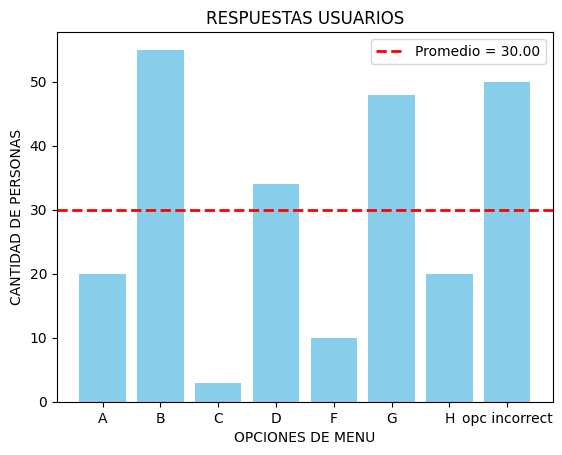

promedio_personas: 30.0


In [ ]:
import matplotlib.pyplot as uio

def promedio(lista):
    suma = sum(lista)
    return suma / len(lista)

# Datos
opciones_menu_principal = ["A", "B", "C", "D", "F", "G", "H", "opc incorrect"]
cant_personas = [20, 55, 3, 34, 10, 48, 20, 50]

# Calcular promedio
prom = promedio(cant_personas)

# Gráfico de barras
uio.bar(opciones_menu_principal, cant_personas, color="skyblue")
uio.title("RESPUESTAS USUARIOS")
uio.xlabel("OPCIONES DE MENU")
uio.ylabel("CANTIDAD DE PERSONAS")

# Línea del promedio
uio.axhline(prom, color="red", linestyle="--", linewidth=2, label=f"Promedio = {prom:.2f}")

# Mostrar leyenda
uio.legend()

# Mostrar gráfico
uio.show()

# Imprimir en consola
print("promedio_personas:", prom)



RE:
- El promedio, en este conjunto de datos no es la mejor medida de análisis porque hay valores muy dispares, muy altos y muy bajos.
El promedio podría ser útil si los valores fueran relativamente parejos.

- Para mejorar el análisis se podría acompañar con mediana y dispersión para tener una imagen más realista.
Mediana: El valor 'del medio' ordenando la lista. Resiste mejor los valores extremos.
Rango o dispersión: Diferencia entre el valor más grande y el más chico.

Otras ideas para mejorar podrían ser:

- Moda: El valor más frecuente. En este caso, la cantidad más repetida de personas.
- Desvío std: Cuanto se alejan, en promedio, los datos respecto al promedio.

- Reducir la cantidad de opciones o considerar solamente las relevantes, Quizás quitar las incorrectas o no tenerlas en cuenta.

- También se podria hacer una suma de la cantidad de personas, y calcular de ese 100% de personas, cuantos eligieron cada opcion, por ejemplo.

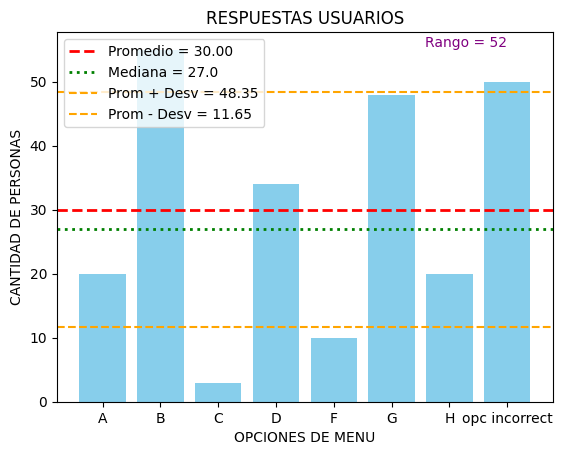

Promedio personas: 30.0
Mediana personas: 27.0
Rango personas: 52
Desvío estándar: 18.350749303502567


In [ ]:
import matplotlib.pyplot as uio
import statistics as stats   # Para mediana y desvío estándar

def promedio(lista):
    return sum(lista) / len(lista)

# Datos
opciones_menu_principal = ["A", "B", "C", "D", "F", "G", "H", "opc incorrect"]
cant_personas = [20, 55, 3, 34, 10, 48, 20, 50]

# Medidas
prom = promedio(cant_personas)
mediana = stats.median(cant_personas)
rango = max(cant_personas) - min(cant_personas)
desvio = stats.pstdev(cant_personas)   # Desvío estándar poblacional

# Gráfico de barras
uio.bar(opciones_menu_principal, cant_personas, color="skyblue")
uio.title("RESPUESTAS USUARIOS")
uio.xlabel("OPCIONES DE MENU")
uio.ylabel("CANTIDAD DE PERSONAS")

# Línea del promedio
uio.axhline(prom, color="red", linestyle="--", linewidth=2, label=f"Promedio = {prom:.2f}")

# Línea de la mediana
uio.axhline(mediana, color="green", linestyle=":", linewidth=2, label=f"Mediana = {mediana}")

# Líneas del desvío estándar (arriba y abajo del promedio)
uio.axhline(prom + desvio, color="orange", linestyle="--", linewidth=1.5, label=f"Prom + Desv = {prom+desvio:.2f}")
uio.axhline(prom - desvio, color="orange", linestyle="--", linewidth=1.5, label=f"Prom - Desv = {prom-desvio:.2f}")

# Texto para el rango
uio.text(len(opciones_menu_principal)-1, max(cant_personas), f"Rango = {rango}",
         ha="right", va="bottom", color="purple", fontsize=10)

# Mostrar leyenda
uio.legend()

# Mostrar gráfico
uio.show()

# Imprimir en consola
print("Promedio personas:", prom)
print("Mediana personas:", mediana)
print("Rango personas:", rango)
print("Desvío estándar:", desvio)



Bot de atención al cliente
#Usuarios


```
lista_usuarios=[usuario1, usuario2, usuario3, usuario4, usuario5]
info_usuario=[DNI, nombre_y_apellido, plan_contratado, saldo_cuenta, dirección]

usuario1=[45465208, "María García", "300M", 0, "Pampa 3128"]
usuario2=[30987221, "Adolfo Perez", "500M", -2000, "Córdoba 2510"]
usuario3=[96876443, "Ana Clara Gonzalez", "500M", 3000, "Scalabrini Ortiz 2020"]
usuario4=[29999545, "Jose Hernández", "300M+Tv", 0, "Alvarez Jonte 1240"]
usuario5=[18776904, "Julio Cortázar", "300M", 20, "Soler 3290"]
```


#Planes


```
300 M 		a $4500
500 M 		a $6000
300 M+Tv 	a $5500
```

El Bot debe
Preguntarle al usuario su DNI y en función de eso saludarlo por su nombre. En el caso de no encontrarse inscripto debe pedirle todos sus datos para ingresarlo(DNI, nombre_y_apellido, plan_contratado, saldo_cuenta, dirección)
Luego de saludarlo informarle qué plan y deuda tiene
Darle la opción de pagar la deuda.
Por último, proponerle cambiar de plan


In [ ]:
# --- Datos iniciales ---
usuarios = {
    # Diccionario de usuarios, donde la clave es el DNI
    # y el valor es una lista con toda la información del cliente.

    45465208: [45465208, "María García", "300M", 0, "Pampa 3128"],       # Usuario 1
    30987221: [30987221, "Adolfo Perez", "500M", -2000, "Córdoba 2510"], # Usuario 2
    96876443: [96876443, "Ana Clara Gonzalez", "500M", 3000, "Scalabrini Ortiz 2020"], # Usuario 3
    29999545: [29999545, "Jose Hernández", "300M+Tv", 0, "Alvarez Jonte 1240"],       # Usuario 4
    18776904: [18776904, "Julio Cortázar", "300M", 20, "Soler 3290"],     # Usuario 5
    24545466: [24545466, "Daniel Sancho", "500M", -6000, "Valcheta 168"] # Usuario 6
}

# Diccionario con los planes disponibles y sus precios.
planes = {
    "300M": 4500,     # Plan de 300 megas cuesta $4500
    "500M": 6000,     # Plan de 500 megas cuesta $6000
    "300M+Tv": 5500   # Plan de 300 megas + TV cuesta $5500
}

# --- Funciones ---
def registrar_usuario(dni):
    """Solicita datos de un usuario nuevo y lo registra."""

    # Pide al usuario que ingrese su nombre y apellido
    nombre = input("Ingrese su nombre y apellido: ")

    # Muestra todos los planes disponibles en pantalla
    print("Planes disponibles:")
    for plan, precio in planes.items():       # Recorre el diccionario planes
        print(f"{plan} \t ${precio}")         # Muestra plan y su precio # \t hace una tabulación


    while True:
      plan = input("Ingrese el plan contratado: ") # Pide que se seleccione un plan
      if plan in planes:   # Verifica si existe en el diccionario
          break
      else:
          print("❌ Plan inválido. Intente nuevamente. Los planes disponibles son:")
          for p, precio in planes.items():
            print(f"{p} \t ${precio}")

    direccion = input("Ingrese su dirección: ")  # Pide la dirección del usuario
    # Registra al nuevo usuario en el diccionario "usuarios"
    # Formato de lista: [dni, nombre, plan, saldo, direccion]
    # El saldo inicial es 0 por defecto.
    usuarios[dni] = [dni, nombre, plan, 0, direccion]

    # Mensaje de confirmación
    print(f"Usuario {nombre} registrado con éxito ✅\n")


def atender_usuario():
    """Función principal del bot de atención al cliente."""

    # Pide el DNI para identificar al usuario
    dni = int(input("Bienvenido al Bot de Atención. Ingrese su DNI: "))

    # Verifica si el DNI está registrado en el diccionario "usuarios"
    if dni in usuarios:
        usuario = usuarios[dni]   # Extrae toda la lista de datos del usuario
        nombre = usuario[1]       # Posición 1 → nombre
        plan = usuario[2]         # Posición 2 → plan contratado
        saldo = usuario[3]        # Posición 3 → saldo de la cuenta (puede ser positivo, negativo o 0)

        # Saludo personalizado
        print(f"\n👋 Hola {nombre}, bienvenido nuevamente.")
        print(f"📌 Plan contratado: {plan}")

        # Caso 1: si tiene deuda (saldo negativo)
        if saldo < 0:
            print(f"💰 Usted tiene una deuda de ${abs(saldo)}.")   # abs() → valor absoluto
            pagar = input("¿Desea pagar ahora? (s/n): ").lower()  # Pregunta si desea pagar, .lower() lo pasa a minúsculas

            # Si responde "s", la deuda se paga (saldo pasa a 0)
            if pagar == "s":
                usuario[3] = 0
                print("✅ Deuda saldada. ¡Gracias por su pago!")

        # Caso 2: si tiene saldo a favor
        elif saldo > 0:
            print(f"💵 Usted tiene un saldo a favor de ${saldo}.")

        # Caso 3: si no tiene deuda ni saldo
        else:
            print("✔️ No tiene deudas ni saldo a favor.")

        # Muestra los planes disponibles por si quiere cambiar
        print("\nPlanes disponibles para cambiar:")
        for p, precio in planes.items():          # Recorre todos los planes
            print(f"{p} \t ${precio}")            # Los imprime con precio

        # Pregunta si desea cambiar de plan
        cambio = input("¿Desea cambiar de plan? (s/n): ").lower() #.lower() transforma la respuesta en minuscula

        # Si quiere cambiar
        if cambio == "s":
            nuevo_plan = input("Ingrese el nuevo plan: ")  # Pide nuevo plan

            # Verifica si el plan existe
            if nuevo_plan in planes:
                usuario[2] = nuevo_plan    # Actualiza el plan en la lista del usuario
                print(f"✅ Cambio realizado. Ahora usted tiene el plan {nuevo_plan}.")
            else:
                print("❌ Plan inválido.") # Si escribe un plan que no está en el diccionario

    # Caso: usuario no registrado en la base
    else:
        print("\n⚠️ Usuario no encontrado.")
        registrar_usuario(dni)  # Llama a la función para registrarlo


# --- Menú Principal en Bucle ---
while True:
    print("\n--- Menú Principal ---\n")
    print("1. Atender a un cliente existente")
    print("2. Registrar un nuevo usuario")
    print("3. Salir")
    opcion = input("\nIngrese una opción: ")

    if opcion == "1":
        atender_usuario()
    elif opcion == "2":
        # Se debe pedir el DNI para registrar a un nuevo usuario
        dni_nuevo = int(input("Ingrese el DNI del nuevo usuario: "))
        registrar_usuario(dni_nuevo)
    elif opcion == "3":
        print("Gracias por usar el servicio. ¡Hasta pronto!")
        break
    else:
        print("Opción inválida. Por favor, intente de nuevo.")


--- Menú Principal ---

1. Atender a un cliente existente
2. Registrar un nuevo usuario
3. Salir

Ingrese una opción: 1
Bienvenido al Bot de Atención. Ingrese su DNI: 35337654

⚠️ Usuario no encontrado.
Ingrese su nombre y apellido: Diego
Planes disponibles:
300M 	 $4500
500M 	 $6000
300M+Tv 	 $5500
Ingrese el plan contratado: 400
❌ Plan inválido. Intente nuevamente. Los planes disponibles son:
300M 	 $4500
500M 	 $6000
300M+Tv 	 $5500
Ingrese el plan contratado: 300M
Ingrese su dirección: local sao
Usuario Diego registrado con éxito ✅


--- Menú Principal ---

1. Atender a un cliente existente
2. Registrar un nuevo usuario
3. Salir

Ingrese una opción: 1
Bienvenido al Bot de Atención. Ingrese su DNI: 35337654

👋 Hola Diego, bienvenido nuevamente.
📌 Plan contratado: 300M
✔️ No tiene deudas ni saldo a favor.

Planes disponibles para cambiar:
300M 	 $4500
500M 	 $6000
300M+Tv 	 $5500
¿Desea cambiar de plan? (s/n): n

--- Menú Principal ---

1. Atender a un cliente existente
2. Registrar